<a href="https://colab.research.google.com/github/SitiMutmainah15/PCVK_GENAP_2026/blob/main/week5_244107020143.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
import math
import glob
import os

<BarContainer object of 256 artists>

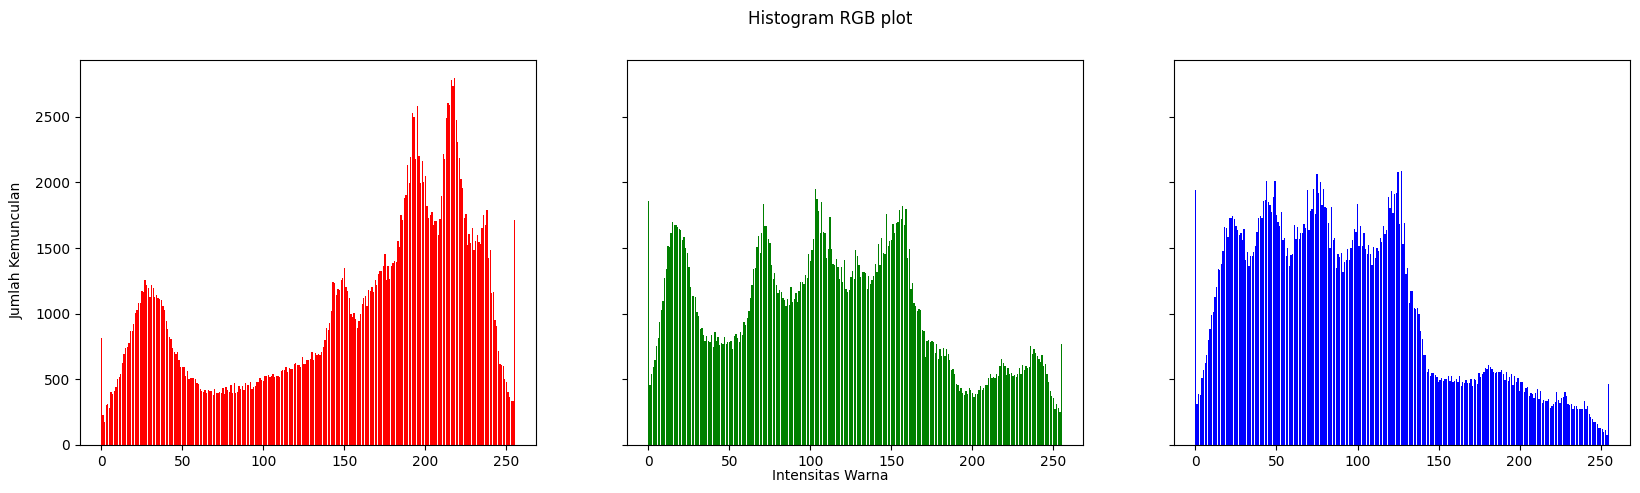

In [36]:
# membuat histogram
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

baca gambar,
amnbil ukuran gambar,
siapkan 256 tempat untuk RGB,
baca setiap pixel,
ambil nilai RGB,
tambah jumlah kemunculan,
tampil histogram,

In [37]:
!ls "/content/drive/MyDrive/PCVK/Images"

'2D Geometry Images'   kitten01.jpg	'Object Detection'
 anna.jpg	      'KTM lama.jpg'	 old_house.jpg
 corak.bmp	       ktp1.jpg		 peppers.jpg
 couple.tiff	       ktp.jpg		 peppers.tiff
 crayfish.jpg	       leaves.jpg	 prabowo.jpg
 crossword.jpg	       lena_gs_lc2.jpg	 romebeauty.jpg
 djawatan.jpg	       lena_gs_lc.jpg	 rose_pink.png
 facedet	       lena.jpg		 sailboat.tiff
 female.tiff	       lena_lc.jpg	 sudoku-original.jpg
 galaxy.jpg	       lily.jpg		 sunset.jpg
 gradient.jpg	       male.tiff	 tank.tiff
 haarcascades	       manalagi.jpg	 teeth.jpg
 houses.jpg	       mandrill2.tiff	 testlena2.jpg
 j.png		       mandrill.tiff	 testlena.jpg
 jungle.png	       noises		 wiki.jpg
 kids.jpeg	       noisy2.png


<BarContainer object of 256 artists>

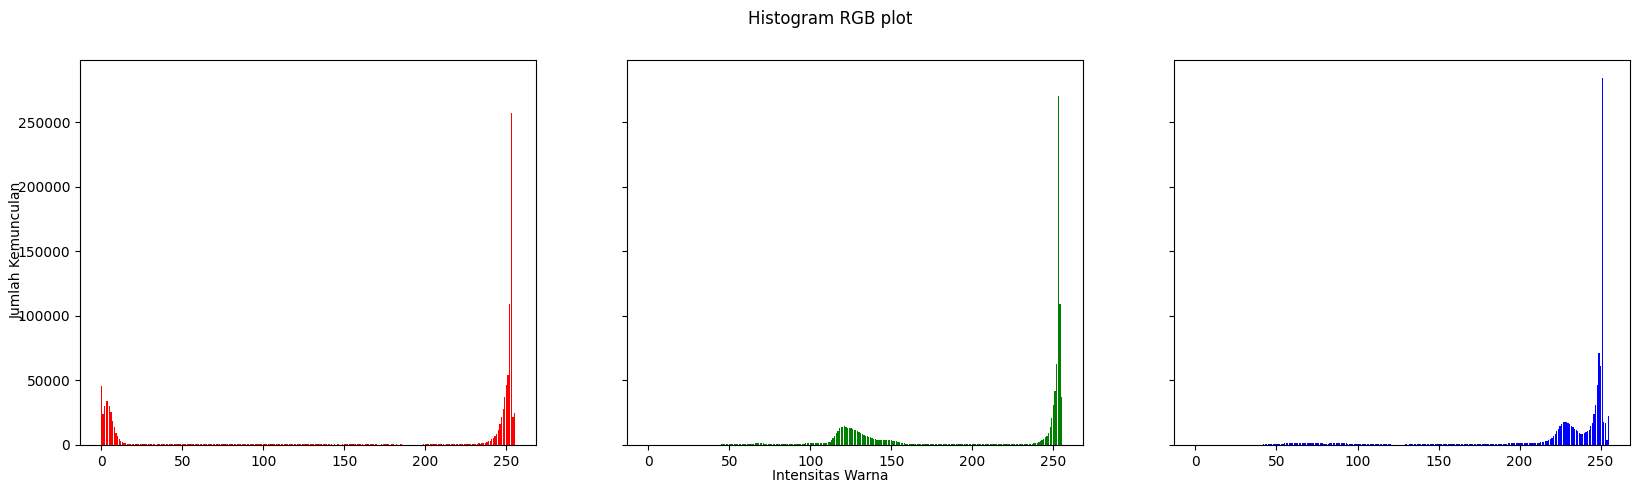

In [38]:
# membuat histogram
img = cv.imread('/content/KTM IIN2.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

grafik ktm tinggi di sebelah kanan karena banyak pixel RGB mendekati 255 (sebagian besar foto berwarna putih).

In [39]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = img.shape

print("Ukuran citra:", img.shape)

Ukuran citra: (512, 512, 3)


In [40]:
#histogram manual
red_manual = [0] * 256
green_manual = [0] * 256
blue_manual = [0] * 256

for y in range(height):
    for x in range(width):
        red_manual[img[y][x][0]] += 1
        green_manual[img[y][x][1]] += 1
        blue_manual[img[y][x][2]] += 1

red_manual = np.array(red_manual)
green_manual = np.array(green_manual)
blue_manual = np.array(blue_manual)

In [41]:
#numpy histrogram
red_numpy, _ = np.histogram(img[:, :, 0], bins=256, range=(0, 256))
green_numpy, _ = np.histogram(img[:, :, 1], bins=256, range=(0, 256))
blue_numpy, _ = np.histogram(img[:, :, 2], bins=256, range=(0, 256))

In [42]:
#cv.calcHist
red_cv = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()
green_cv = cv.calcHist([img], [1], None, [256], [0, 256]).flatten()
blue_cv = cv.calcHist([img], [2], None, [256], [0, 256]).flatten()

In [43]:
print("=== CHANNEL RED ===")
print("Manual vs NumPy  :", np.max(np.abs(red_manual - red_numpy)))
print("Manual vs OpenCV :", np.max(np.abs(red_manual - red_cv)))
print("NumPy vs OpenCV  :", np.max(np.abs(red_numpy - red_cv)))

print("\n=== CHANNEL GREEN ===")
print("Manual vs NumPy  :", np.max(np.abs(green_manual - green_numpy)))
print("Manual vs OpenCV :", np.max(np.abs(green_manual - green_cv)))
print("NumPy vs OpenCV  :", np.max(np.abs(green_numpy - green_cv)))

print("\n=== CHANNEL BLUE ===")
print("Manual vs NumPy  :", np.max(np.abs(blue_manual - blue_numpy)))
print("Manual vs OpenCV :", np.max(np.abs(blue_manual - blue_cv)))
print("NumPy vs OpenCV  :", np.max(np.abs(blue_numpy - blue_cv)))

=== CHANNEL RED ===
Manual vs NumPy  : 0
Manual vs OpenCV : 0.0
NumPy vs OpenCV  : 0.0

=== CHANNEL GREEN ===
Manual vs NumPy  : 0
Manual vs OpenCV : 0.0
NumPy vs OpenCV  : 0.0

=== CHANNEL BLUE ===
Manual vs NumPy  : 0
Manual vs OpenCV : 0.0
NumPy vs OpenCV  : 0.0


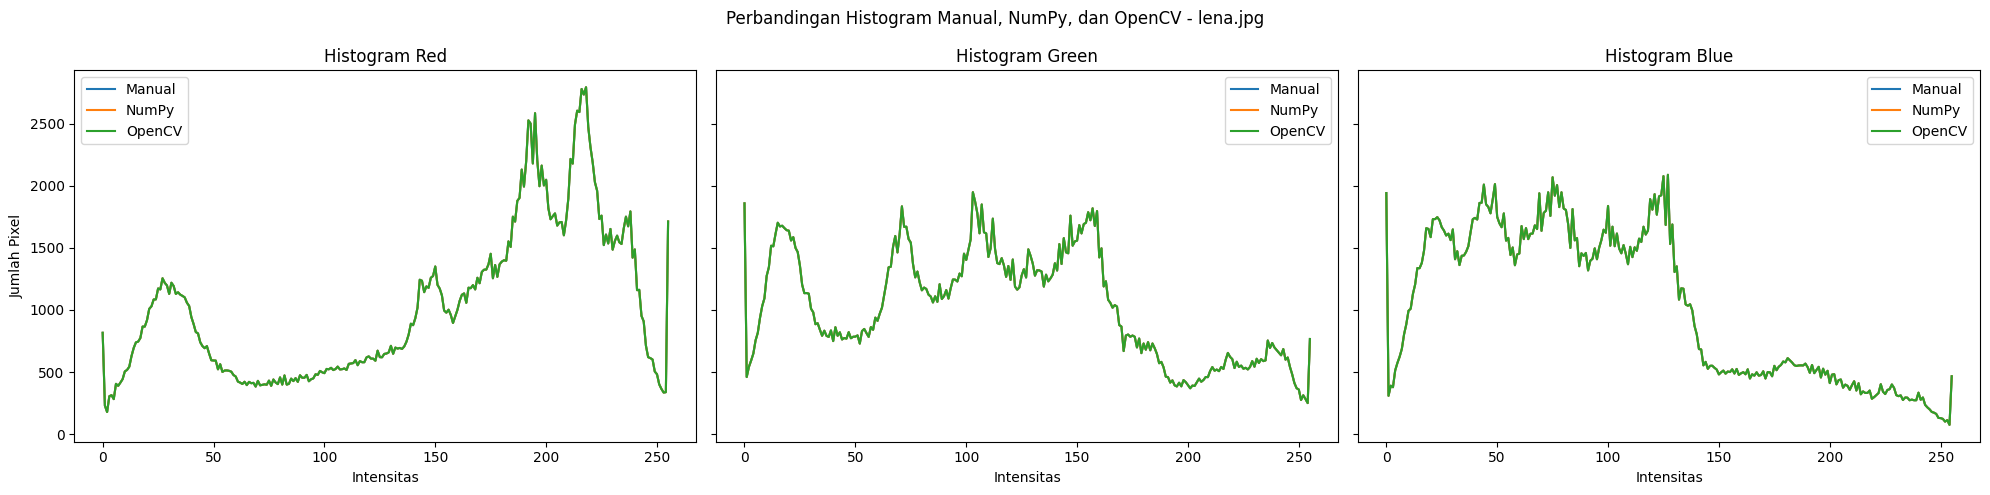

In [44]:
names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

# RED
axs[0].plot(names, red_manual, label='Manual')
axs[0].plot(names, red_numpy, label='NumPy')
axs[0].plot(names, red_cv, label='OpenCV')
axs[0].set_title('Histogram Red')
axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Jumlah Pixel')
axs[0].legend()

# GREEN
axs[1].plot(names, green_manual, label='Manual')
axs[1].plot(names, green_numpy, label='NumPy')
axs[1].plot(names, green_cv, label='OpenCV')
axs[1].set_title('Histogram Green')
axs[1].set_xlabel('Intensitas')
axs[1].legend()

# BLUE
axs[2].plot(names, blue_manual, label='Manual')
axs[2].plot(names, blue_numpy, label='NumPy')
axs[2].plot(names, blue_cv, label='OpenCV')
axs[2].set_title('Histogram Blue')
axs[2].set_xlabel('Intensitas')
axs[2].legend()

fig.suptitle('Perbandingan Histogram Manual, NumPy, dan OpenCV - lena.jpg')

plt.tight_layout()
plt.show()

disini muncul hanya 1 garis hijau karena ketiga histogrammenghasilkan nilai yang sama persis, sehingga garisnya menumpuk

In [45]:
img = cv.imread('/content/KTM IIN2.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = img.shape

print("Ukuran citra:", img.shape)

Ukuran citra: (828, 1301, 3)


In [46]:
#histogram manual
red_manual = [0] * 256
green_manual = [0] * 256
blue_manual = [0] * 256

for y in range(height):
    for x in range(width):
        red_manual[img[y][x][0]] += 1
        green_manual[img[y][x][1]] += 1
        blue_manual[img[y][x][2]] += 1

red_manual = np.array(red_manual)
green_manual = np.array(green_manual)
blue_manual = np.array(blue_manual)

In [47]:
#numpy histrogram
red_numpy, _ = np.histogram(img[:, :, 0], bins=256, range=(0, 256))
green_numpy, _ = np.histogram(img[:, :, 1], bins=256, range=(0, 256))
blue_numpy, _ = np.histogram(img[:, :, 2], bins=256, range=(0, 256))

In [48]:
#cv.calcHist
red_cv = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()
green_cv = cv.calcHist([img], [1], None, [256], [0, 256]).flatten()
blue_cv = cv.calcHist([img], [2], None, [256], [0, 256]).flatten()

In [49]:
print("=== CHANNEL RED ===")
print("Manual vs NumPy  :", np.max(np.abs(red_manual - red_numpy)))
print("Manual vs OpenCV :", np.max(np.abs(red_manual - red_cv)))
print("NumPy vs OpenCV  :", np.max(np.abs(red_numpy - red_cv)))

print("\n=== CHANNEL GREEN ===")
print("Manual vs NumPy  :", np.max(np.abs(green_manual - green_numpy)))
print("Manual vs OpenCV :", np.max(np.abs(green_manual - green_cv)))
print("NumPy vs OpenCV  :", np.max(np.abs(green_numpy - green_cv)))

print("\n=== CHANNEL BLUE ===")
print("Manual vs NumPy  :", np.max(np.abs(blue_manual - blue_numpy)))
print("Manual vs OpenCV :", np.max(np.abs(blue_manual - blue_cv)))
print("NumPy vs OpenCV  :", np.max(np.abs(blue_numpy - blue_cv)))

=== CHANNEL RED ===
Manual vs NumPy  : 0
Manual vs OpenCV : 0.0
NumPy vs OpenCV  : 0.0

=== CHANNEL GREEN ===
Manual vs NumPy  : 0
Manual vs OpenCV : 0.0
NumPy vs OpenCV  : 0.0

=== CHANNEL BLUE ===
Manual vs NumPy  : 0
Manual vs OpenCV : 0.0
NumPy vs OpenCV  : 0.0


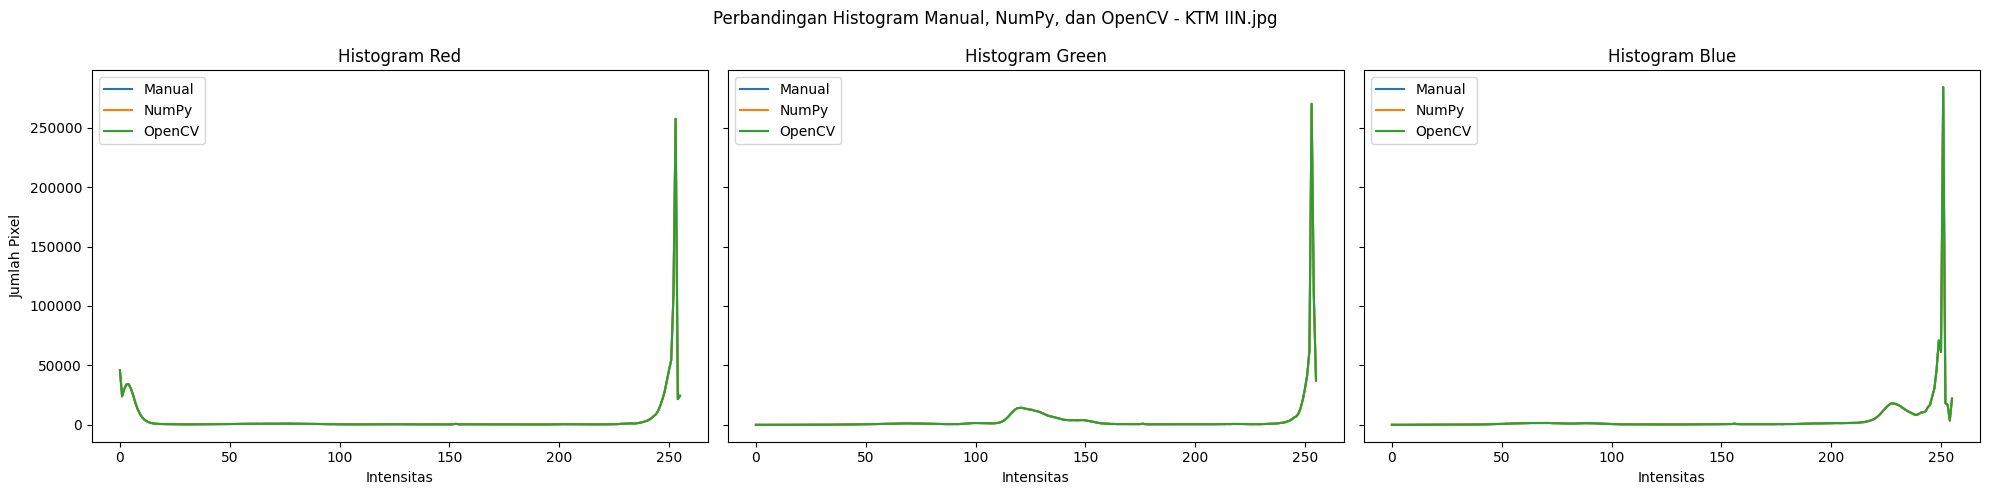

In [50]:
names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

# RED
axs[0].plot(names, red_manual, label='Manual')
axs[0].plot(names, red_numpy, label='NumPy')
axs[0].plot(names, red_cv, label='OpenCV')
axs[0].set_title('Histogram Red')
axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Jumlah Pixel')
axs[0].legend()

# GREEN
axs[1].plot(names, green_manual, label='Manual')
axs[1].plot(names, green_numpy, label='NumPy')
axs[1].plot(names, green_cv, label='OpenCV')
axs[1].set_title('Histogram Green')
axs[1].set_xlabel('Intensitas')
axs[1].legend()

# BLUE
axs[2].plot(names, blue_manual, label='Manual')
axs[2].plot(names, blue_numpy, label='NumPy')
axs[2].plot(names, blue_cv, label='OpenCV')
axs[2].set_title('Histogram Blue')
axs[2].set_xlabel('Intensitas')
axs[2].legend()

fig.suptitle('Perbandingan Histogram Manual, NumPy, dan OpenCV - KTM IIN.jpg')

plt.tight_layout()
plt.show()